# Import Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


# Data Collection

In [7]:
gold_dataset = pd.read_csv("/content/extracted_archive/gld_price_data.csv")

# Data Preprocessing

In [43]:
# printing the 1st 5 rows of the dataset
gold_dataset.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [9]:
# Information about the dataset
gold_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [10]:
# The last five entities of the dataset
gold_dataset.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [13]:
# total number of rows and coulmns in the dataset
gold_dataset.shape

(2290, 6)

In [14]:
# Checking for missing values
gold_dataset.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [15]:
#Statistical meaures of the dataset
gold_dataset.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


# Correlation between different columns --- its imp to find in regression problem

1.Positive Correlation -- one value increase other increase too

2.Negative Coorrelation --- one value decrease other decrease too

In [17]:
#calculating the correlation of all the columns except of the Date due to the datastype String
correlation = gold_dataset.drop('Date', axis=1).corr()

<Axes: >

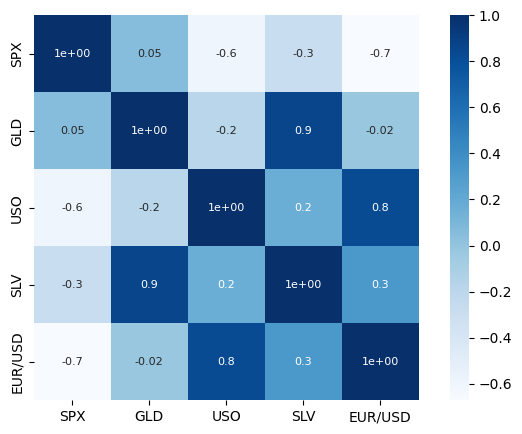

In [22]:
#Constructing the heatmap to understand the correlation
plt.figure(figsize=(8,5))
sns.heatmap(correlation , cbar=True , square = True , fmt = '.1' , annot = True , annot_kws={'size':8} , cmap = 'Blues' )

In [19]:
#Correlation values of Gold
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_11561/240033533.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_dataset['GLD'] , color = 'green')


<Axes: xlabel='GLD', ylabel='Density'>

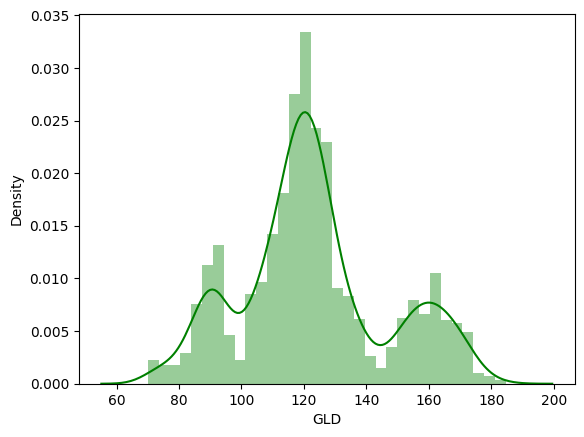

In [23]:
# Checking the distribution of the GLD Price
sns.distplot(gold_dataset['GLD'] , color = 'green')

Distribution --- average of the GLD price is 120
             ---- in start its 80
             ----- in end its 124
             ----- so average price is 120

# Data Splitting
-- Features X
--- Target Y

In [24]:
X = gold_dataset.drop(['Date' , 'GLD'], axis=1)
y = gold_dataset['GLD']

# Separating the model as Training or Testing data

In [27]:
# Train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [28]:
# Check the shape of the X
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(2290, 4)
(1832, 4)
(458, 4)


# Model Training

## Random Forest Model --
 #### is a collection of Decision Tree -- n_number of Decision Tree -- RFR check the mean values of all the decision tree and make final output

In [29]:
# Model Creation
regressor = RandomForestRegressor(n_estimators=100, random_state=0)

In [30]:
# Model Training
regressor.fit(X_train,y_train)

RandomForestRegressor(random_state=0)

# Evaultion on Training Data


# r2_score
#### is a error score , in our case the values are in 100 - 124 range  so the error score is 0.99 which is not that much that means the model is performing well if incase the dataset values are in 1-5 range then this error 0.99 is to much but now this is acceptable score of error

In [33]:
# Prediction on training data
training_data_prediction = regressor.predict(X_train)
from sklearn.metrics import r2_score
r2_score_on_training_data = r2_score(training_data_prediction , y_train)

In [34]:
# printing the prediction
print(training_data_prediction)
print(r2_score_on_training_data)

[158.73969526 121.16220141  94.44350156 ... 152.94479691 119.3834996
 167.5657979 ]
0.9986421369142237


# Evalution on Testing Data

In [35]:
#Prediction on testing data
testing_data_prediction = regressor.predict(X_test)
r2_score_on_testing_data = r2_score(testing_data_prediction , y_test)


In [36]:
#printing the prediction
print(testing_data_prediction)
print(r2_score_on_testing_data)

[122.65873753 130.63480289 127.66999982  96.65079779 118.93220068
 114.47599921 124.77220126 117.73529926 107.88840118  98.33599976
  95.24969985 167.91109885 149.16060125 115.73670052 170.6228019
  85.36579964 123.09429878 109.3994972  113.38210044 131.60350269
 124.29839892 113.55450071 115.73500041 108.58329959 108.38580113
 125.76569904 119.69089965 112.26199919 113.52610136 125.09079882
 146.05780139  89.44870005 167.49899968 113.79139901 108.35130079
 120.17450083 141.66589769 161.38270061 174.34089811 153.07030138
 119.11820138 113.52490079 121.3074995  113.70209945 122.09150032
 107.93640077  88.48999918 114.50649907 130.10110231 118.00860103
 103.12470011 130.13650225 107.27639864 160.71050312 131.77390008
 118.25009987 147.07830098 135.76720211  95.69580098 124.69110131
 114.81049848  86.35560091 104.29099906 114.04520065  84.01499908
 122.3354003  116.67739913 113.74500221 165.87870299  92.32210048
  79.94390079 161.03020056 159.16290252 106.88229991 149.56180116
 109.397997

# Compare the Actual values and Predicted values by Plotting

In [37]:
# convert the y_test into list datatype
y_test = list(y_test)

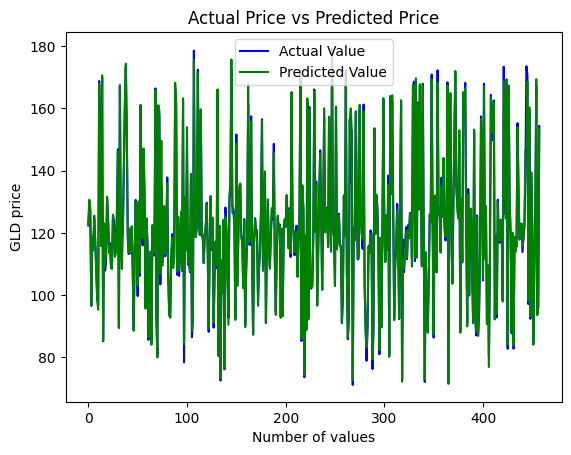

In [40]:
#plotting using matplotlib.pyplot and seaborn
plt.plot(y_test , color = 'blue' , label = 'Actual Value')
plt.plot(testing_data_prediction , color = 'green' , label = 'Predicted Value')
plt.title("Actual Price vs Predicted Price")
plt.xlabel('Number of values')
plt.ylabel('GLD price')
plt.legend()
plt.show()

# Predictive System For Gold Price

In [41]:
print("Enter the Following Values to Predict Gold Price (GLD) : ")

SPX_input = float(input("SPX (S&P 500 index) : ") )
USO_input = float(input("USO (Oil Fund Price) : "))
SLV_input = float(input("SLV (Silver Price) : " ))
EUR_USD_input = float(input("EUR/USD :"))

#Arrange the input into the same format as the training data(X)

input_data = pd.DataFrame([[SPX_input, USO_input, SLV_input, EUR_USD_input]] ,
                          columns = ['SPX', 'USO', 'SLV', 'EUR/USD'])
# Make Prediction using the trained regressor
predicted_price = regressor.predict(input_data)

print("Predicted Gold Price (GLD) : " , predicted_price[0])

Enter the Following Values to Predict Gold Price (GLD) : 
SPX (S&P 500 index) : 2730.129883
USO (Oil Fund Price) : 31.842221
SLV (Silver Price) : 20.084997
EUR/USD :1.474491
Predicted Gold Price (GLD) :  130.1759003
